## Load Libraries

In [252]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import root_mean_squared_error,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

## Dataset Load

In [215]:
df=pd.DataFrame(pd.read_csv("customer_churn.csv"))

## Basic Inspection

In [4]:
df

,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,SupportCalls,Churn
0,23,53,142.05,Month-to-month,Fiber optic,Mailed check,9,No
1,65,64,143.19,Month-to-month,Fiber optic,Credit card,3,No
2,58,41,89.68,Two year,Fiber optic,Mailed check,8,No
3,45,30,52.61,One year,Fiber optic,Bank transfer,0,No
4,44,0,116.11,One year,Fiber optic,Mailed check,7,Yes
...,...,...,...,...,...,...,...,...
99995,79,40,43.50,Month-to-month,Fiber optic,Bank transfer,6,Yes
99996,19,25,100.76,Month-to-month,DSL,Electronic check,2,No
99997,53,8,45.82,Month-to-month,DSL,Bank transfer,6,No
99998,18,65,34.24,Month-to-month,DSL,Credit card,0,No


In [5]:
df.head()

,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,SupportCalls,Churn
0,23,53,142.05,Month-to-month,Fiber optic,Mailed check,9,No
1,65,64,143.19,Month-to-month,Fiber optic,Credit card,3,No
2,58,41,89.68,Two year,Fiber optic,Mailed check,8,No
3,45,30,52.61,One year,Fiber optic,Bank transfer,0,No
4,44,0,116.11,One year,Fiber optic,Mailed check,7,Yes


In [6]:
df.shape

(100000, 8)

In [11]:
df.columns

Index(['Age', 'Tenure', 'MonthlyCharges', 'Contract', 'InternetService',
       'PaymentMethod', 'SupportCalls', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Age              100000 non-null  int64  
 1   Tenure           100000 non-null  int64  
 2   MonthlyCharges   100000 non-null  float64
 3   Contract         100000 non-null  object 
 4   InternetService  100000 non-null  object 
 5   PaymentMethod    100000 non-null  object 
 6   SupportCalls     100000 non-null  int64  
 7   Churn            100000 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 6.1+ MB


In [12]:
df.describe()

,Age,Tenure,MonthlyCharges,SupportCalls
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,48.490250,36.082420,84.913534,5.007570
std,17.892246,21.058885,37.545104,3.158597
min,18.000000,0.000000,20.000000,0.000000
25%,33.000000,18.000000,52.240000,2.000000
50%,49.000000,36.000000,84.720000,5.000000
75%,64.000000,54.000000,117.470000,8.000000
max,79.000000,72.000000,150.000000,10.000000


In [14]:
df.isnull().sum()

Age                0
Tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
PaymentMethod      0
SupportCalls       0
Churn              0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [23]:
df.tail()

,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,SupportCalls,Churn
99995,79,40,43.50,Month-to-month,Fiber optic,Bank transfer,6,Yes
99996,19,25,100.76,Month-to-month,DSL,Electronic check,2,No
99997,53,8,45.82,Month-to-month,DSL,Bank transfer,6,No
99998,18,65,34.24,Month-to-month,DSL,Credit card,0,No
99999,76,67,25.55,Month-to-month,Fiber optic,Electronic check,4,No


In [24]:
df.dtypes

Age                  int64
Tenure               int64
MonthlyCharges     float64
Contract            object
InternetService     object
PaymentMethod       object
SupportCalls         int64
Churn               object
dtype: object

In [25]:
df["Contract"].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [28]:
df["Contract"].value_counts()

Contract
Month-to-month    54901
One year          25072
Two year          20027
Name: count, dtype: int64

## EDA:- Exploratory Data Analysis

In [31]:
df["Churn"].value_counts()

Churn
No     73313
Yes    26687
Name: count, dtype: int64

## Target Visualization

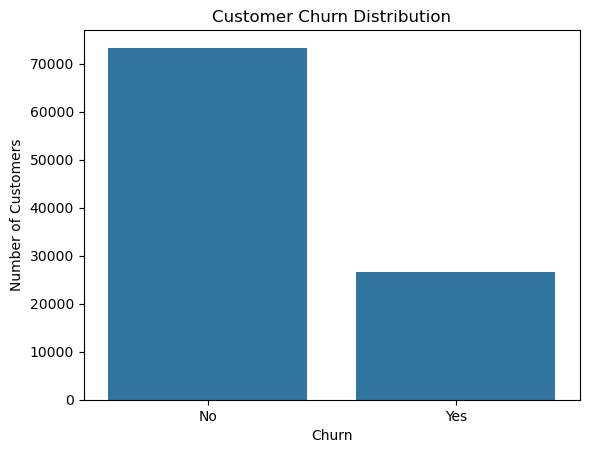

In [39]:
sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Numerical Distribution

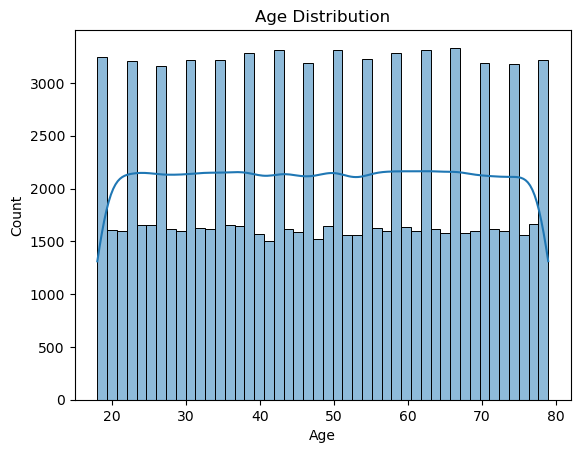

In [48]:
sns.histplot(data=df, x="Age", kde=True)

plt.title("Age Distribution")
plt.show()

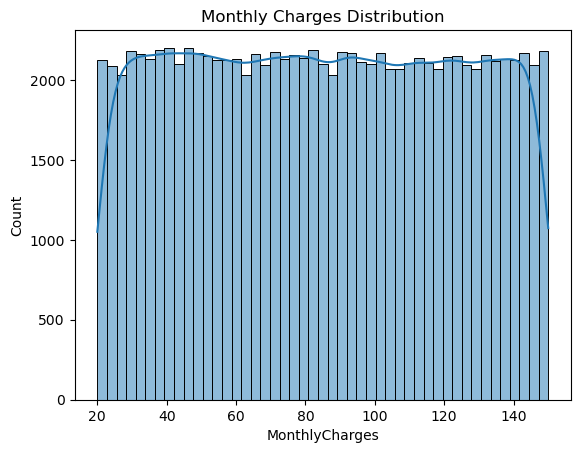

In [49]:
sns.histplot(data=df, x="MonthlyCharges", kde=True)

plt.title("Monthly Charges Distribution")
plt.show()

## Boxplot — Outliers

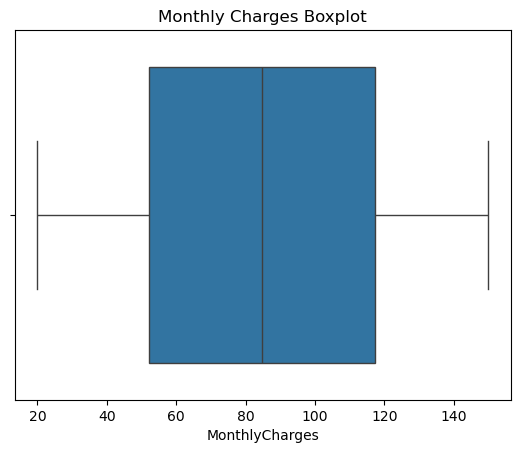

In [50]:
sns.boxplot(data=df, x="MonthlyCharges")

plt.title("Monthly Charges Boxplot")
plt.show()

## Categorical Features

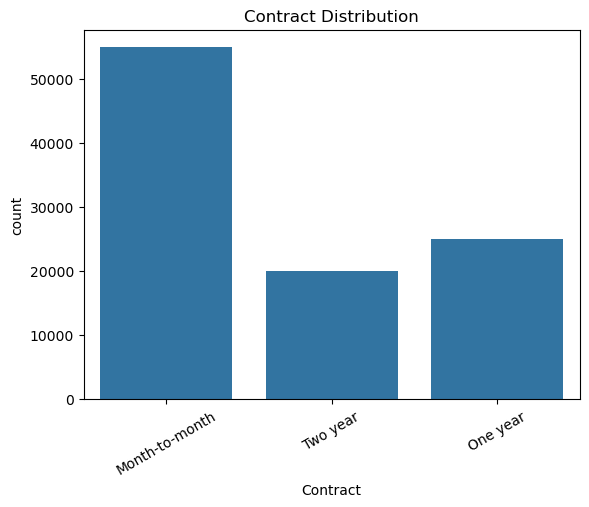

In [51]:
sns.countplot(data=df, x="Contract")

plt.title("Contract Distribution")
plt.xticks(rotation=30)
plt.show()

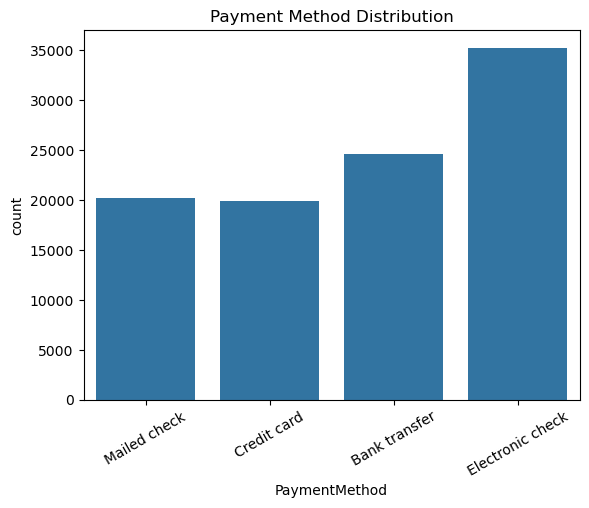

In [52]:
sns.countplot(data=df, x="PaymentMethod")

plt.title("Payment Method Distribution")
plt.xticks(rotation=30)
plt.show()

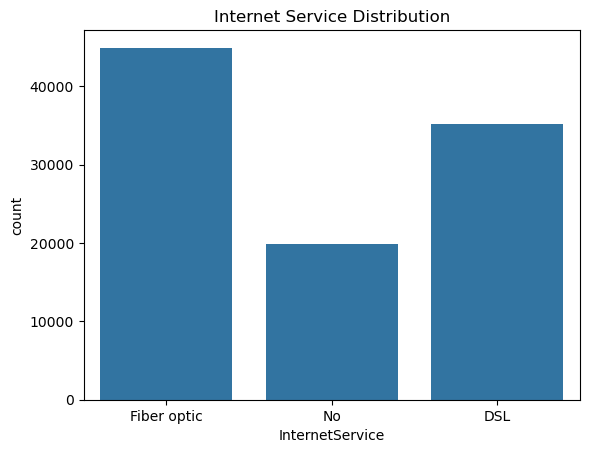

In [53]:
sns.countplot(data=df, x="InternetService")

plt.title("Internet Service Distribution")
plt.show()

## Feature vs Target

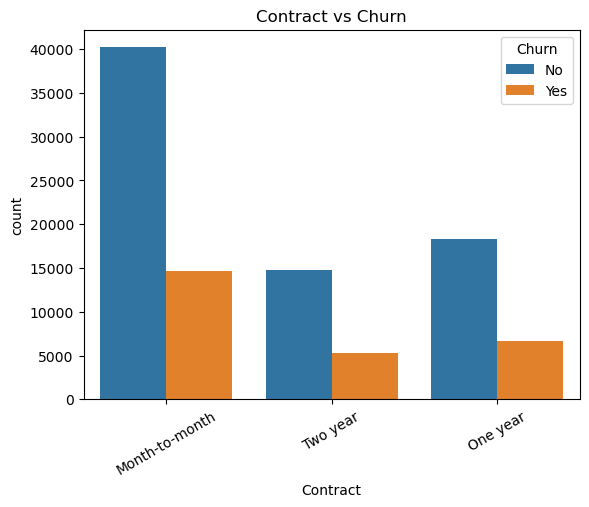

In [54]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract vs Churn")
plt.xticks(rotation=30)
plt.show()

## Numerical Feature vs Churn

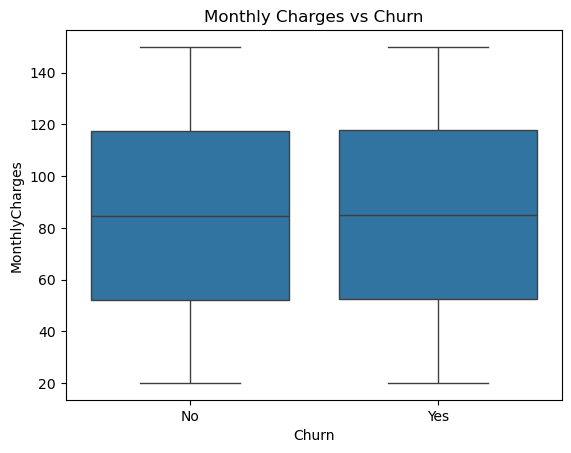

In [56]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

## Correlation

In [58]:
corr = df[numeric_features].corr()

corr

,Age,Tenure,MonthlyCharges,SupportCalls
Age,1.000000,-0.005025,-0.000532,-0.005179
Tenure,-0.005025,1.000000,-0.000280,-0.000799
MonthlyCharges,-0.000532,-0.000280,1.000000,-0.002559
SupportCalls,-0.005179,-0.000799,-0.002559,1.000000


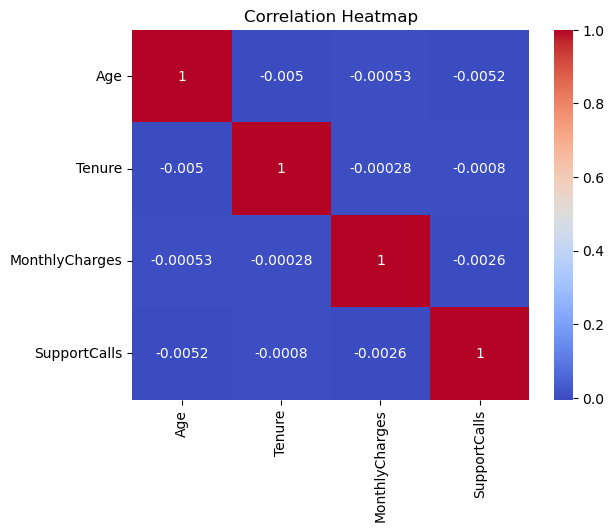

In [59]:
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

## X and Y Separete

In [216]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [169]:
X.head()

,Age,Tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,SupportCalls
0,23,53,142.05,Month-to-month,Fiber optic,Mailed check,9
1,65,64,143.19,Month-to-month,Fiber optic,Credit card,3
2,58,41,89.68,Two year,Fiber optic,Mailed check,8
3,45,30,52.61,One year,Fiber optic,Bank transfer,0
4,44,0,116.11,One year,Fiber optic,Mailed check,7


In [170]:
y.head()

0     No
1     No
2     No
3     No
4    Yes
Name: Churn, dtype: object

In [171]:
print(X.shape)
print(y.shape)

(100000, 7)
(100000,)


## Train-Test Split

In [217]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [173]:
print("X_train columns:")
print(X_train.columns.tolist())

print("\nNumerical:")
print(X_train.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical:")
print(X_train.select_dtypes(exclude=np.number).columns.tolist())

X_train columns:
['Age', 'Tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'PaymentMethod', 'SupportCalls']

Numerical:
['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls']

Categorical:
['Contract', 'InternetService', 'PaymentMethod']


## Split verify

In [218]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80000, 7)
X_test : (20000, 7)
y_train: (80000,)
y_test : (20000,)


## Numerical/Categorical Columns Identify

In [219]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

In [220]:
print(numerical_features)

['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls']


In [221]:
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

In [222]:
print(categorical_features)

['Contract', 'InternetService', 'PaymentMethod']


## Numerical Pipeline

In [223]:
numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

In [200]:
numerical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

## Categorical Pipeline

In [224]:
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(sparse_output=False))])

In [202]:
categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(sparse_output=False))])

## ColumnTransformer/ Complete Pipeline

In [225]:
complete_pipeline = ColumnTransformer(
    [
        (
            "number",
            numerical_pipeline,
            X_train.select_dtypes(
                include=np.number
            ).columns.tolist()
        ),
        (
            "category",
            categorical_pipeline,
            X_train.select_dtypes(
                exclude=np.number
            ).columns.tolist()
        )
    ],
    verbose_feature_names_out=False,
    verbose=True
).set_output(transform="pandas")

In [204]:
(complete_pipeline)

ColumnTransformer(transformers=[('number',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Tenure', 'MonthlyCharges',
                                  'SupportCalls']),
                                ('category',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(sparse_output=False))]),
                                 ['Contract', 'InternetService',
                                  'PaymentMethod'])],
                  verbose=True, verbose_feature_names_out=False)

In [205]:
#X_train= complete_pipeline.fit_transform(X_train)

[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s


In [158]:
#X_train.head()

,Age,Tenure,MonthlyCharges,SupportCalls,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
93223,1.145578,1.613555,1.380139,1.262035,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
49892,0.530834,-1.616185,-0.922735,-0.636220,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
10821,-0.810427,1.043601,-1.297566,-1.268972,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5990,-1.536943,0.806120,1.706948,0.312908,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
64979,-0.866312,-0.618765,-0.539101,1.262035,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


In [159]:
#print(X_train.shape)

(80000, 14)


In [206]:
#X_test= complete_pipeline.transform(X_test)

In [207]:
#X_test.head()

,Age,Tenure,MonthlyCharges,SupportCalls,Contract_Month-to-month,Contract_One year,Contract_Two year,InternetService_DSL,InternetService_Fiber optic,InternetService_No,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
46360,-1.145742,-1.426200,1.088544,0.629283,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
20005,-1.033970,1.281082,1.040257,0.945659,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12283,-1.201628,-0.381284,0.666760,0.629283,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
74821,0.922035,-0.713758,-1.468574,0.629283,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
85207,-1.257513,1.423570,-1.444830,-1.585347,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [208]:
#print(X_test.shape)

(20000, 14)


## Model Select

In [226]:
model= RandomForestClassifier(random_state=42)

In [227]:
model

RandomForestClassifier(random_state=42)

## Model Pipeline

In [228]:
model_pipeline = Pipeline([
    ("preprocessor", complete_pipeline),
    ("model", RandomForestClassifier(random_state=42))
])

In [229]:
model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'SupportCalls']),
                                                 ('category',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod'])],
                                   verbose=True,
                                   verbose_feature_names_out=False)),
                ('model', RandomForestClassifier(random_state=42))])

## Model Fit

In [230]:
model_pipeline.fit(X_train, y_train)

[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'SupportCalls']),
                                                 ('category',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod'])],
                                   verbose=True,
                                   verbose_feature_names_out=False)),
                ('model', RandomForestClassifier(random_state=42))])

## Predication

In [231]:
y_pred = model_pipeline.predict(X_test)

In [193]:
print(y_pred[:10])

['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No']


In [232]:
print(y_test[:10].values)

['No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No']


## Model Evaluation

In [234]:
accuracy = accuracy_score(y_test, y_pred)

In [235]:
accuracy

0.71225

## Precision

In [237]:
precision = precision_score(y_test,y_pred,pos_label="Yes")

In [238]:
precision

0.26410835214446954

## Recall

In [240]:
recall = recall_score(y_test,y_pred,pos_label="Yes")

In [241]:
recall

0.04384485666104553

## F1 Score

In [246]:
f1 = f1_score(y_test,y_pred,pos_label="Yes")

In [247]:
f1

0.07520488510364776

## Confusion Matrix

In [248]:
cm = confusion_matrix(y_test,y_pred,labels=["No", "Yes"])

In [249]:
cm

array([[14011,   652],
       [ 5103,   234]], dtype=int64)

## Cross Validation

In [250]:
cv_scores = cross_val_score(model_pipeline,X_train,y_train,cv=5,scoring="accuracy")

[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s
[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s
[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.0s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s
[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s
[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s


In [251]:
print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

CV Scores: [0.712125  0.715125  0.7115    0.7090625 0.71275  ]
Mean CV Score: 0.7121124999999999


## GridSearchCV

In [253]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [258]:
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [259]:
grid_search

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('number',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Tenure',
                                                                          'MonthlyCharges',
                                                                          'SupportCalls']),
                                                                        ('category',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(sparse_output=False))]),
                                                                         ['Contract',
                                                                          'InternetService',
                                                                          'PaymentMethod'])],
                                                          verbose=True,
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

In [260]:
grid_search.fit(X_train, y_train)

[ColumnTransformer] ........ (1 of 2) Processing number, total=   0.1s
[ColumnTransformer] ...... (2 of 2) Processing category, total=   0.1s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('number',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Tenure',
                                                                          'MonthlyCharges',
                                                                          'SupportCalls']),
                                                                        ('category',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(sparse_output=False))]),
                                                                         ['Contract',
                                                                          'InternetService',
                                                                          'PaymentMethod'])],
                                                          verbose=True,
                                                          verbose_feature_names_out=False)),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

## Best Parameters

In [261]:
print(grid_search.best_params_)

{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [262]:
print(grid_search.best_score_)

0.733125


## Best Model

In [263]:
best_model = grid_search.best_estimator_

In [264]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Tenure',
                                                   'MonthlyCharges',
                                                   'SupportCalls']),
                                                 ('category',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['Contract',
                                                   'InternetService',
                                                   'PaymentMethod'])],
                                   verbose=True,
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [265]:
y_pred_tuned = best_model.predict(X_test)

In [266]:
y_pred_tuned

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

## New Customer Prediction

In [267]:
new_customer = pd.DataFrame({
    "Age": [35],
    "Tenure": [24],
    "MonthlyCharges": [75.50],
    "Contract": ["Month-to-month"],
    "InternetService": ["Fiber optic"],
    "PaymentMethod": ["Credit card"],
    "SupportCalls": [3]
})

In [268]:
prediction = best_model.predict(new_customer)

print("Prediction:", prediction)

Prediction: ['No']


In [269]:
probability = best_model.predict_proba(new_customer)

print(probability)

[[0.73015801 0.26984199]]


In [270]:
print(best_model.classes_)

['No' 'Yes']


## Model Save

In [271]:
import joblib

joblib.dump(
    best_model,
    "customer_churn_model.pkl"
)

['customer_churn_model.pkl']